In [14]:
import torch
import torchvision
from torchvision import datasets, transforms
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time

Funkcja do trenowania sieci neuronowej. Dokładniejszy opis treningu znajduje się w jednym z poprzednich wykładów. Dla obecnego tematu nie jest to kluczowe zagadnienie.

In [83]:
def fit(model, epochs, device, train_loader, val_loader, criterion, optimizer, max_patience):
    best_loss = float('inf') #przechowujemy najlepszy błąd 
    start_time = time.time() #przy okazji będziemy mogli porównać czasy uczenia!
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0  #przechowuje średni błąd podczas epoki
        patience = 0        #przechowuje ilość iteracji, kiedy nie wystąpiła poprawa na zbiorze walidacyjnym
        #pętla treningowa
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_avg_loss = running_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {train_avg_loss:.4f}")

        #walidacja modelu
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        print(f"Validation Accuracy: {100 * correct / total:.2f}%")

        #warunek wczesnego stopu
        val_loss_avg = val_loss/len(val_loader)
        if val_loss_avg < best_loss:
            best_loss = val_loss_avg
            patience = 0
        else:
            patience += 1
            if patience > max_patience:
                print("Early stopping!")
                break

    end_time = time.time()
    print(f"Training time: {end_time - start_time:.2f} seconds")

#### Hiperparametry

In [86]:
#rozmiar pojedynczej paczki danych, na podstawie której wykonywany będzie krok spadku gradientowego
BATCH_SIZE = 500
#maksymalna ilość epok treningowych
NUM_EPOCHS = 10
#ilość wymaganych epok, podczas których nie nastąpiła poprawa na zbiorze walidacyjnym, do zatrzymania treningu
MAX_PATIENCE = 3

#### Najpierw pobierzemy zbiór danych CIFAR10

In [7]:
transform = transforms.Compose([
    transforms.Resize((224,224)),      # przeskalowanie do rozdzielczości 224x224
    transforms.ToTensor(),             # zmiana na tensor
])

In [8]:
#pobieranie danych treningowych
train = datasets.CIFAR10(root='Datasets', 
                         train=True, 
                         download=False, 
                         transform=transform)

#pobieranie danych walidacyjnych
val = datasets.CIFAR10(root='Datasets',        
                        train=False, 
                        download=True, 
                        transform=transform)

In [12]:
#przygotowanie struktury DataLoader do wczytywania danych
train_loader = DataLoader(train, batch_size=500, shuffle=True)
val_loader = DataLoader(val, batch_size=500, shuffle=False)

#### Zobaczmy jak będzie wyglądał zbiór, na którym będziemy eksperymentować

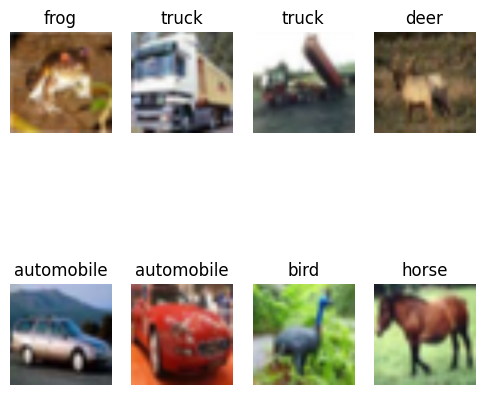

In [27]:
fig, axes = plt.subplots(2, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    img, label = train[i]
    img_np = np.transpose(img.numpy(), (1, 2, 0))  # CHW → HWC

    ax.imshow(img_np)
    ax.set_title(train.classes[label])
    ax.axis("off")

#### W celu nauczenia się pobranego zbioru wykorzystamy architekturę sieci AlexNet, stworzonej do klasyfikacji obrazków ze zbioru danych ImageNet. Pierwszy eksperyment przeprowadzimy bez używania wag pochodzących z pretreningu.

In [ ]:
#pobieramy model bez pretrenowanych wag
model = torch.hub.load('pytorch/vision:v0.10.0', 'alexnet', pretrained=False)

In [4]:
model.eval()

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

Przed propagacją danych przez model AlexNet musimy zmodyfikować jego ostatnią warstwę - jak widać powyżej ostatnia warstwa liniowa posiada 1000 neuronów wyjściowych, ponieważ ImageNet, na którym model był oryginalnie trenowany, zawiera aż 1000 klas zdjęć. Zmienimy ilość jednostek wyjśćiowych na 10, czyli ilość klas w obecnie analizowanym zbiorze danych.

In [101]:
model.classifier[6] = nn.Linear(model.classifier[6].in_features, 10)

In [102]:
#ustawianie urządzenia - obliczenia wykonujemy na karcie graficznej, jeżeli jest dostępna
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [103]:
criterion = nn.CrossEntropyLoss()       #funkcja straty
optimizer = optim.Adam(model.parameters(), lr=0.001)    #algorytm spadku gradientowego

In [104]:
#trenowanie modelu i walidacja
fit(model = model, 
    epochs = NUM_EPOCHS, 
    device = device, 
    train_loader = train_loader, 
    val_loader = val_loader, 
    criterion = criterion, 
    optimizer = optimizer, 
    max_patience = MAX_PATIENCE)

Epoch [1/10], Loss: 2.2081
Validation Accuracy: 31.74%
Epoch [2/10], Loss: 1.7530
Validation Accuracy: 43.73%
Epoch [3/10], Loss: 1.4812
Validation Accuracy: 51.11%
Epoch [4/10], Loss: 1.3201
Validation Accuracy: 55.94%
Epoch [5/10], Loss: 1.2023
Validation Accuracy: 59.78%
Epoch [6/10], Loss: 1.1131
Validation Accuracy: 62.63%
Epoch [7/10], Loss: 1.0346
Validation Accuracy: 64.89%
Epoch [8/10], Loss: 0.9578
Validation Accuracy: 67.09%
Epoch [9/10], Loss: 0.9099
Validation Accuracy: 68.95%
Epoch [10/10], Loss: 0.8472
Validation Accuracy: 67.55%
Training time: 424.23 seconds


Możemy zaobserwować, że model po 10 epokach całkiem dobrze nauczył się klasyfikować obrazki ze zbioru. Jednocześnie widoczne są pewne rzeczy, które spróbujemy poprawić - brak pretreningu powoduje, że model musi uczyć się wszystkiego od początku, przez co trafność na początkowych epokach jest niska. Dodatkowo nawet końcowy rezultat nie jest powalający - jesteśmy w stanie uzyskać o wiele więcej, niż 70%!

#### Teraz, kiedy zaobserwowaliśmy przebieg treningu modelu inicjalizowanego losowo, porównajmy go z treningiem tej samej architektury AlexNet wyposażonej w pretrenowane wagi, pochodzące z treningu na zbiorze ImageNet.

In [ ]:
#zmieniamy parametr "pretrained" na True, aby pobrac model pretrenowany
model = torch.hub.load('pytorch/vision:v0.10.0', 'alexnet', pretrained=True)
#pozostałe instrukcję powtarzamy z kroku poprzedniego
model.classifier[6] = nn.Linear(model.classifier[6].in_features, 10)
model = model.to(device)

In [94]:
#ponownie wybieramy funckję straty i optymalizator
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001) #mniejszy learning rate dla modelu pretrenowanego

In [95]:
#trenowanie modelu i walidacja
fit(model = model, 
    epochs = NUM_EPOCHS, 
    device = device, 
    train_loader = train_loader, 
    val_loader = val_loader, 
    criterion = criterion, 
    optimizer = optimizer, 
    max_patience = MAX_PATIENCE)

Epoch [1/10], Loss: 0.8565
Validation Accuracy: 80.52%
Epoch [2/10], Loss: 0.4535
Validation Accuracy: 85.86%
Epoch [3/10], Loss: 0.3414
Validation Accuracy: 87.74%
Epoch [4/10], Loss: 0.2712
Validation Accuracy: 89.02%
Epoch [5/10], Loss: 0.2139
Validation Accuracy: 89.52%
Epoch [6/10], Loss: 0.1760
Validation Accuracy: 89.90%
Epoch [7/10], Loss: 0.1387
Validation Accuracy: 90.48%
Epoch [8/10], Loss: 0.1060
Validation Accuracy: 90.69%
Epoch [9/10], Loss: 0.0893
Validation Accuracy: 90.03%
Epoch [10/10], Loss: 0.0732
Validation Accuracy: 90.16%
Training time: 454.83 seconds


Tak jak widzimy model pretrenowany poradził sobie o wiele lepiej! Używając pretrenowanych wag otrzymaliśmy poprawę o niecałe 20 punktów procentowych pomimo, że oryginalne parametry nie były dobierane dla zbioru CIFAR10!

#### Następnie zbadamy wpływ zamrażania warstw sieci podczas treningu - w tym podejściu pierwsze dwie warstwy konwolucyjne nie będą uaktualniane w trakcie uczenia. Początkowe warstwy sieci neuronowych zwykle uczą się ogólnych cech zbioru danych, które powinny być łatwe do generalizacji na inne zadania.

In [ ]:
#ponownie wybieramy model pretrenowany
model = torch.hub.load('pytorch/vision:v0.10.0', 'alexnet', pretrained=True)

#tym razem mrozimy warstwy konwolucyjne modelu
for param in model.features[0].parameters():
    param.requires_grad = False

for param in model.features[3].parameters():
    param.requires_grad = False

#pozostałe instrukcję powtarzamy z kroku poprzedniego
model.classifier[6] = nn.Linear(model.classifier[6].in_features, 10)
model = model.to(device)

In [97]:
criterion = nn.CrossEntropyLoss()
#ponieważ nie chcemy tracić czasu na obliczenia dla warstw zamrożonych,
#odfiltrowujemy parametry modelu, których nie będziemy zmieniać
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)

In [98]:
#trenowanie modelu i walidacja
fit(model = model, 
    epochs = NUM_EPOCHS, 
    device = device, 
    train_loader = train_loader, 
    val_loader = val_loader, 
    criterion = criterion, 
    optimizer = optimizer, 
    max_patience = MAX_PATIENCE)

Epoch [1/10], Loss: 0.8712
Validation Accuracy: 80.32%
Epoch [2/10], Loss: 0.5013
Validation Accuracy: 84.37%
Epoch [3/10], Loss: 0.3944
Validation Accuracy: 85.79%
Epoch [4/10], Loss: 0.3175
Validation Accuracy: 87.87%
Epoch [5/10], Loss: 0.2574
Validation Accuracy: 87.45%
Epoch [6/10], Loss: 0.2091
Validation Accuracy: 88.01%
Epoch [7/10], Loss: 0.1745
Validation Accuracy: 88.99%
Epoch [8/10], Loss: 0.1440
Validation Accuracy: 89.06%
Epoch [9/10], Loss: 0.1189
Validation Accuracy: 89.25%
Epoch [10/10], Loss: 0.0962
Validation Accuracy: 89.29%
Training time: 404.22 seconds


Jak widzimy model, w którym pierwsze warstwy zostały zamrożone, poradził sobie porównywalnie dobrze na naszym zbiorze. Warto zauważyć spadek czasu treningu wynikający z mniejszej liczby trenowalnych parametrów (tutaj wliczany jest również czas walidacji, który jest równy w obu przypadkach, ponieważ w jego trakcie nie aktualizujemy żadnych parametrów).